# Problem Statement:

To develop a machine learning model that classify the quality of water samples
using water chemistry measurements.


The goal is to support early decision making and risk identification for water
quality management.

# Dataset Description

All attributes are numeric variables and they are listed bellow:

- aluminium - dangerous if greater than 2.8
- ammonia - dangerous if greater than 32.5
- arsenic - dangerous if greater than 0.01
- barium - dangerous if greater than 2
- cadmium - dangerous if greater than 0.005
- chloramine - dangerous if greater than 4
- chromium - dangerous if greater than 0.1
- copper - dangerous if greater than 1.3
- flouride - dangerous if greater than 1.5
- bacteria - dangerous if greater than 0
- viruses - dangerous if greater than 0
- lead - dangerous if greater than 0.015
- nitrates - dangerous if greater than 10
- nitrites - dangerous if greater than 1
- mercury - dangerous if greater than 0.002
- perchlorate - dangerous if greater than 56
- radium - dangerous if greater than 5
- selenium - dangerous if greater than 0.5
- silver - dangerous if greater than 0.1
- uranium - dangerous if greater than 0.3
- is_safe - class attribute {0 - not safe, 1 - safe}

# Importing the Dependencies

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import joblib

#1. Data Preparation
Preparing the Data for the further use of Analysis & Prediction

## Read Data Files

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mssmartypants/water-quality")

print("Path to dataset files:", path)

100%|██████████| 258k/258k [00:00<00:00, 58.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mssmartypants/water-quality/versions/3


In [ ]:
water_df = pd.read_csv(path + "/waterQuality1.csv")

In [ ]:
# Checking the null values
water_df.isnull().sum()

,0
aluminium,0
ammonia,0
arsenic,0
barium,0
cadmium,0
chloramine,0
chromium,0
copper,0
flouride,0
bacteria,0


Since there is no missing values so we can move forward

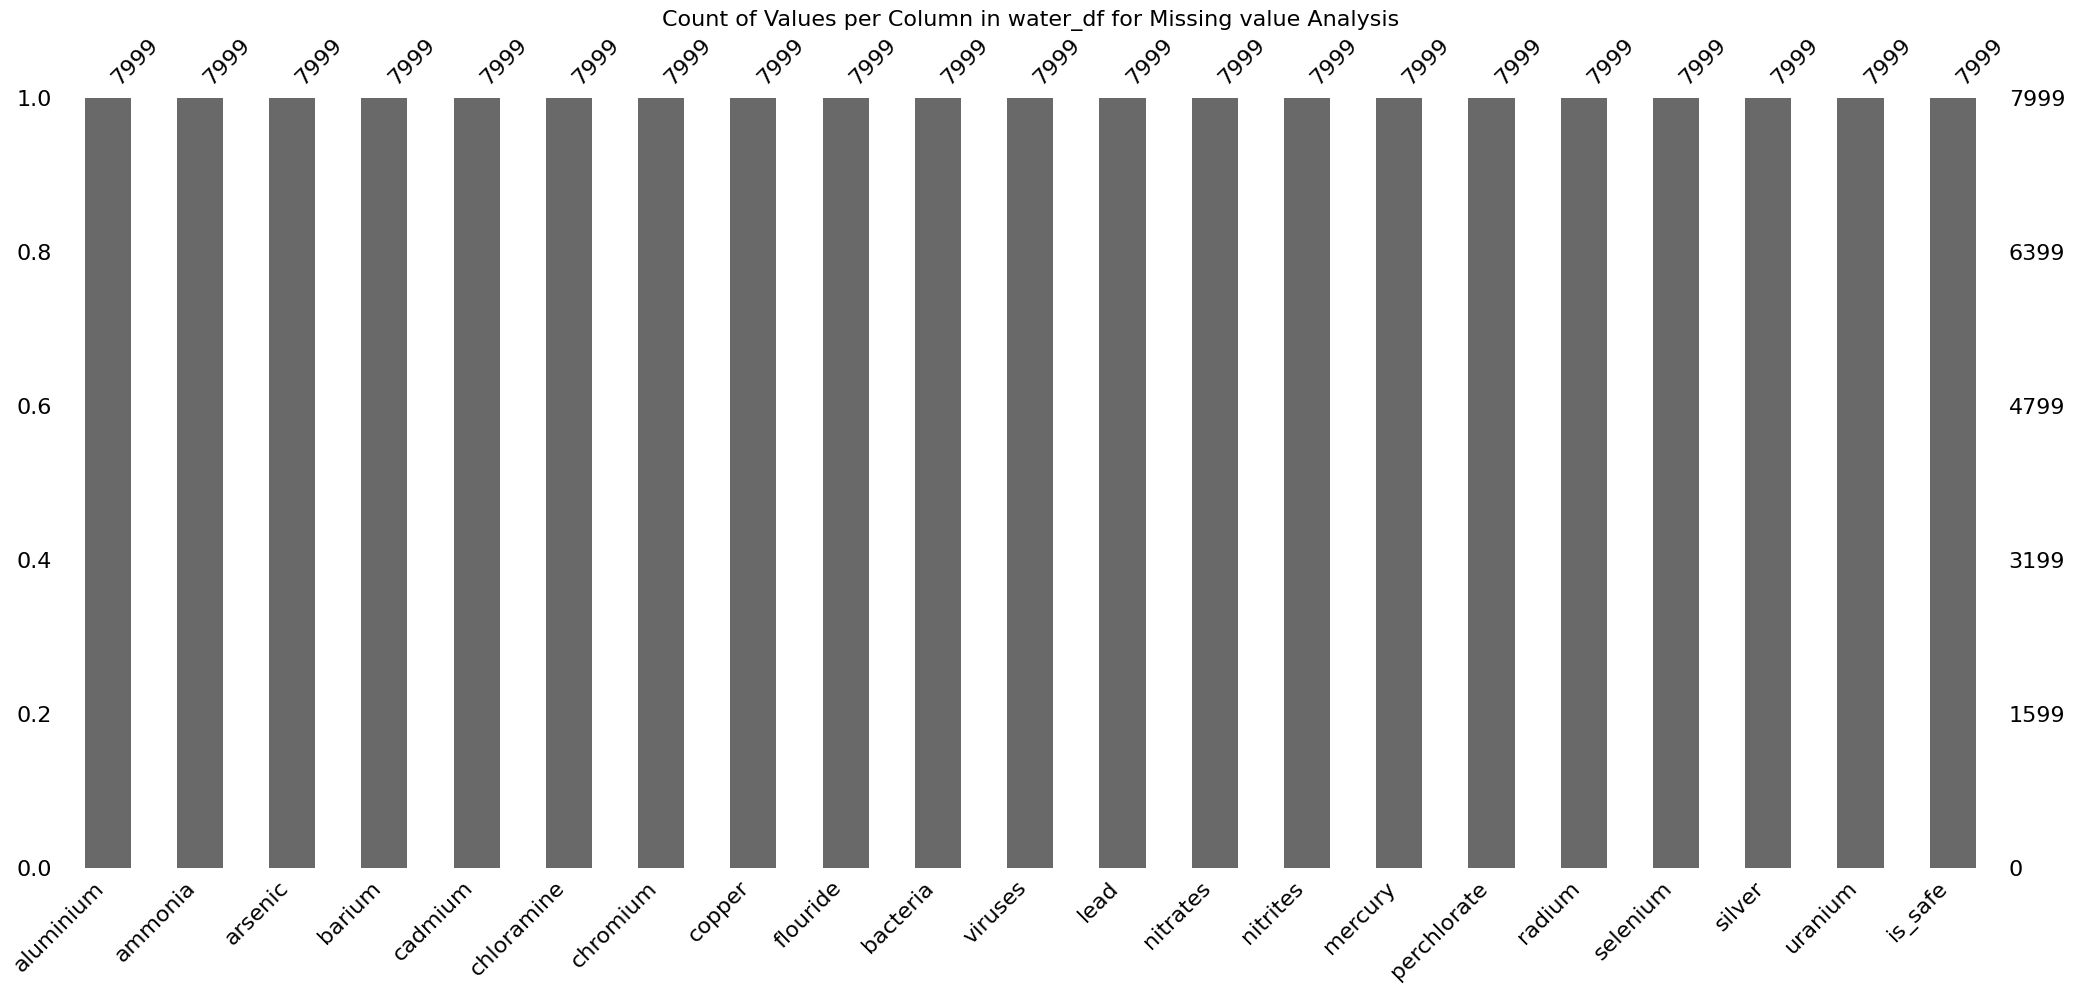

In [ ]:
import missingno as msno
msno.bar(water_df)
plt.title('Count of Values per Column in water_df for Missing value Analysis', size=16)
plt.show()

In [ ]:
# Printing the Head of the dataset
water_df.head()

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
0,1.65,9.08,0.04,2.85,0.007,0.35,0.83,0.17,0.05,0.20,...,0.054,16.08,1.13,0.007,37.75,6.78,0.08,0.34,0.02,1
1,2.32,21.16,0.01,3.31,0.002,5.28,0.68,0.66,0.90,0.65,...,0.100,2.01,1.93,0.003,32.26,3.21,0.08,0.27,0.05,1
2,1.01,14.02,0.04,0.58,0.008,4.24,0.53,0.02,0.99,0.05,...,0.078,14.16,1.11,0.006,50.28,7.07,0.07,0.44,0.01,0
3,1.36,11.33,0.04,2.96,0.001,7.23,0.03,1.66,1.08,0.71,...,0.016,1.41,1.29,0.004,9.12,1.72,0.02,0.45,0.05,1
4,0.92,24.33,0.03,0.20,0.006,2.67,0.69,0.57,0.61,0.13,...,0.117,6.74,1.11,0.003,16.90,2.41,0.02,0.06,0.02,1


In [ ]:
water_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7999 entries, 0 to 7998
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   aluminium    7999 non-null   float64
 1   ammonia      7999 non-null   object 
 2   arsenic      7999 non-null   float64
 3   barium       7999 non-null   float64
 4   cadmium      7999 non-null   float64
 5   chloramine   7999 non-null   float64
 6   chromium     7999 non-null   float64
 7   copper       7999 non-null   float64
 8   flouride     7999 non-null   float64
 9   bacteria     7999 non-null   float64
 10  viruses      7999 non-null   float64
 11  lead         7999 non-null   float64
 12  nitrates     7999 non-null   float64
 13  nitrites     7999 non-null   float64
 14  mercury      7999 non-null   float64
 15  perchlorate  7999 non-null   float64
 16  radium       7999 non-null   float64
 17  selenium     7999 non-null   float64
 18  silver       7999 non-null   float64
 19  uraniu

## Conversion of Datatypes

In [ ]:
water_df['ammonia'] = pd.to_numeric(water_df['ammonia'], errors='coerce')
water_df['is_safe'] = pd.to_numeric(water_df['is_safe'], errors='coerce')

In [ ]:
water_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7999 entries, 0 to 7998
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   aluminium    7999 non-null   float64
 1   ammonia      7996 non-null   float64
 2   arsenic      7999 non-null   float64
 3   barium       7999 non-null   float64
 4   cadmium      7999 non-null   float64
 5   chloramine   7999 non-null   float64
 6   chromium     7999 non-null   float64
 7   copper       7999 non-null   float64
 8   flouride     7999 non-null   float64
 9   bacteria     7999 non-null   float64
 10  viruses      7999 non-null   float64
 11  lead         7999 non-null   float64
 12  nitrates     7999 non-null   float64
 13  nitrites     7999 non-null   float64
 14  mercury      7999 non-null   float64
 15  perchlorate  7999 non-null   float64
 16  radium       7999 non-null   float64
 17  selenium     7999 non-null   float64
 18  silver       7999 non-null   float64
 19  uraniu

## Dropping Null values

In [ ]:
water_df = water_df.dropna()

## Remove Duplications

In [ ]:
water_df.duplicated().sum()

np.int64(0)

since no duplicates found in this dataset

In [ ]:
water_df.shape

(7996, 21)

# 2: Exploratory Data Analysis

## 2.1: Descriptive Analysis

In [ ]:
water_df.describe()

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
count,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,...,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000
mean,0.666396,14.278212,0.161477,1.567928,0.042803,2.177589,0.247300,0.805940,0.771646,0.319714,...,0.099431,9.819250,1.329846,0.005193,16.465266,2.920106,0.049684,0.147811,0.044672,0.114057
std,1.265323,8.878930,0.252632,1.216227,0.036049,2.567210,0.270663,0.653595,0.435423,0.329497,...,0.058169,5.541977,0.573271,0.002967,17.688827,2.322805,0.028773,0.143569,0.026906,0.317900
min,0.000000,-0.080000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.040000,6.577500,0.030000,0.560000,0.008000,0.100000,0.050000,0.090000,0.407500,0.000000,...,0.048000,5.000000,1.000000,0.003000,2.170000,0.820000,0.020000,0.040000,0.020000,0.000000
50%,0.070000,14.130000,0.050000,1.190000,0.040000,0.530000,0.090000,0.750000,0.770000,0.220000,...,0.102000,9.930000,1.420000,0.005000,7.745000,2.410000,0.050000,0.080000,0.050000,0.000000
75%,0.280000,22.132500,0.100000,2.482500,0.070000,4.240000,0.440000,1.390000,1.160000,0.610000,...,0.151000,14.610000,1.760000,0.008000,29.487500,4.670000,0.070000,0.240000,0.070000,0.000000
max,5.050000,29.840000,1.050000,4.940000,0.130000,8.680000,0.900000,2.000000,1.500000,1.000000,...,0.200000,19.830000,2.930000,0.010000,60.010000,7.990000,0.100000,0.500000,0.090000,1.000000


## 2.2: Class Distribution

In [ ]:
water_df["is_safe"].value_counts()

,count
is_safe,
0.0,7084
1.0,912


In [ ]:
water_df["is_safe"].value_counts(normalize=True)

,proportion
is_safe,
0.0,0.885943
1.0,0.114057


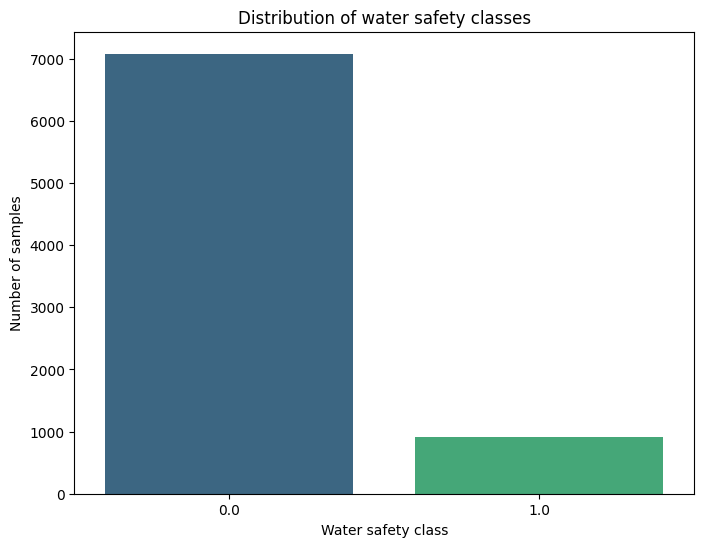

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x=water_df['is_safe'], hue=water_df['is_safe'], palette='viridis', legend=False)
plt.xlabel("Water safety class")
plt.ylabel("Number of samples")
plt.title("Distribution of water safety classes")
plt.show()

The class distribution shows that the dataset is imbalanced

Therefore, stratified sampling is required during train-test splitting.

## 2.3: Distribution of important chemical parameters

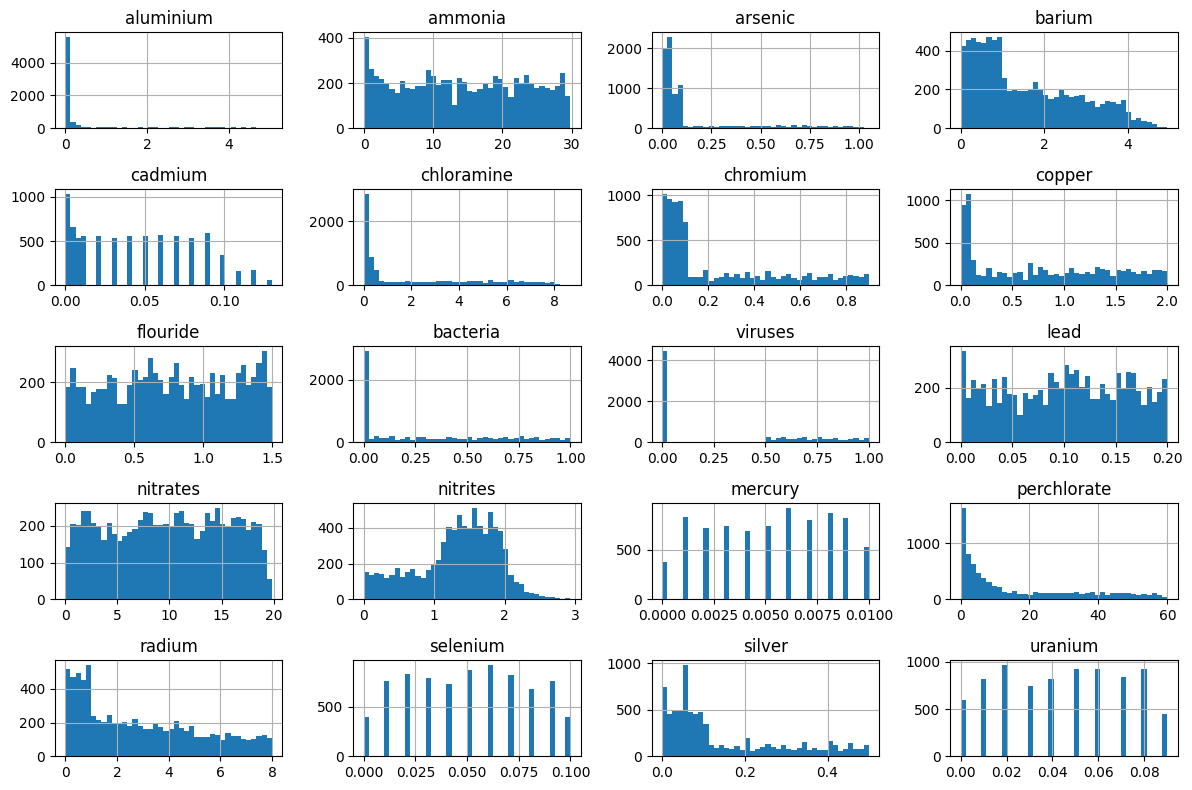

In [ ]:
cols_to_plot = water_df.columns.tolist()
cols_to_plot.remove("is_safe")

water_df[cols_to_plot].hist(bins=40, figsize=(12,8))
plt.tight_layout()
plt.show()

## 2.4: Outlier inspection

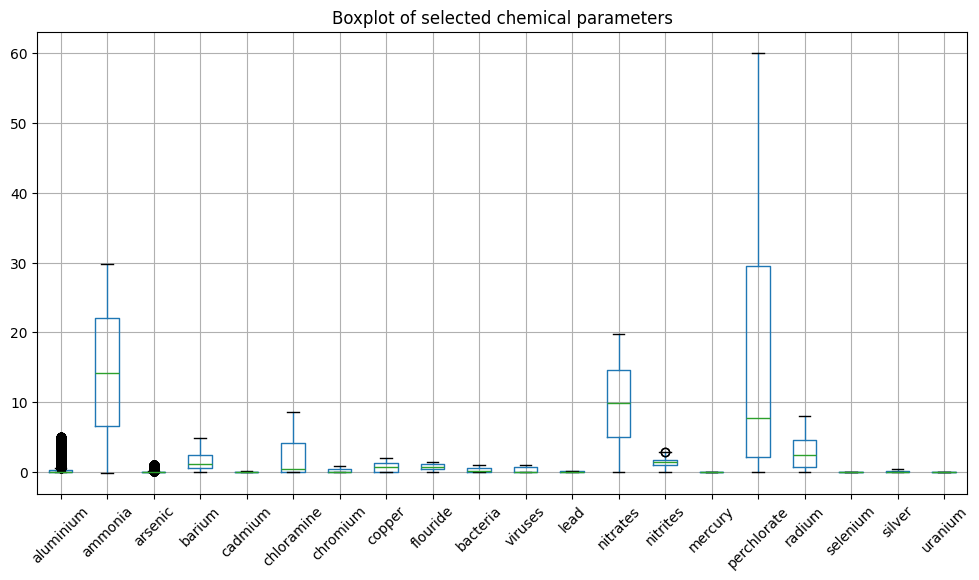

In [ ]:
plt.figure(figsize=(12,6))
water_df[cols_to_plot].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot of selected chemical parameters")
plt.show()

Several parameters show extreme values.

These are not necessarily noise, but may represent highly contaminated
water samples. Therefore, outliers are retained rather than removed.

## 2.5: Correlation Heatmap

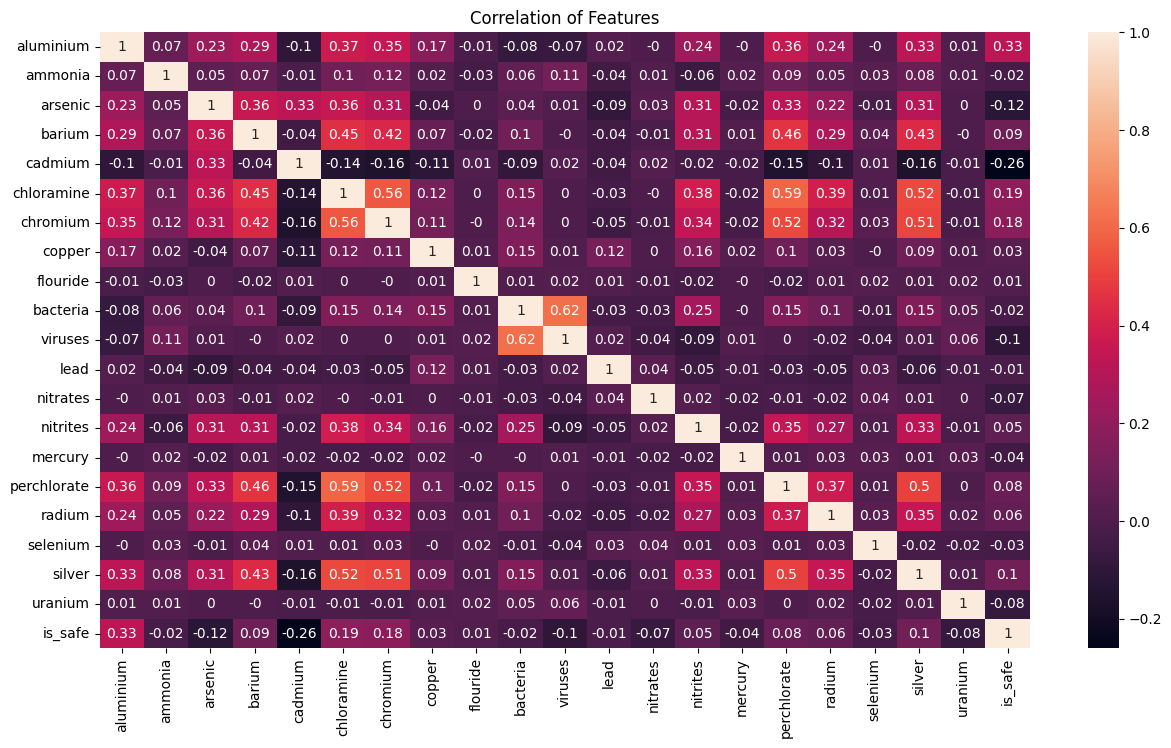

In [ ]:
plt.figure(figsize=(15,8))
sns.heatmap(water_df.corr().round(2), annot=True)
plt.title("Correlation of Features")
plt.show()

Most water chemistry parameters show weak to moderate correlations.

### Top 10 Features by Correlation

In [ ]:
corr = water_df.corr()
corr_with_water_df = corr['is_safe'].sort_values(ascending=False).drop(['is_safe'])
corr_with_water_df = corr_with_water_df.head(10)

/tmp/ipykernel_4074/544860241.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_water_df.index, y=corr_with_water_df.values, palette='viridis')


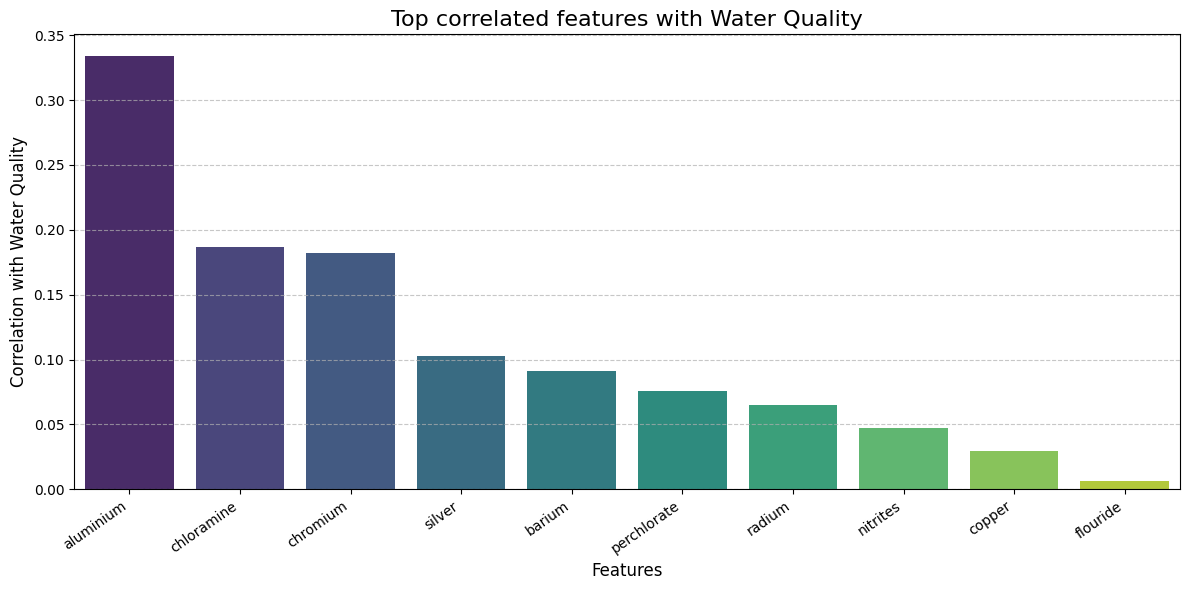

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=corr_with_water_df.index, y=corr_with_water_df.values, palette='viridis')
plt.title('Top correlated features with Water Quality', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Correlation with Water Quality', fontsize=12)
plt.xticks(rotation=35, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Pairplot

In [ ]:
# sns.pairplot(water_df)
# plt.title("Pairplot for clusters of Demand Features")
# plt.show()

## 2.6: Relationship between chemistry and safety class

In [ ]:
grouped = water_df.groupby("is_safe")[cols_to_plot].mean()
grouped

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,viruses,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium
is_safe,,,,,,,,,,,,,,,,,,,,
0.0,0.514780,14.351222,0.172659,1.528281,0.046115,2.005621,0.229596,0.799023,0.770623,0.322324,0.341871,0.099639,9.962612,1.320182,0.005232,15.984616,2.866150,0.050003,0.142516,0.045402
1.0,1.844079,13.711096,0.074624,1.875888,0.017081,3.513355,0.384814,0.859671,0.779594,0.299441,0.226451,0.097815,8.705680,1.404912,0.004888,20.198739,3.339211,0.047204,0.188947,0.039002


The mean values of several chemical parameters are significantly higher
in unsafe water samples compared to safe samples.

This confirms that chemical concentrations play a decisive role in
water safety classification.

# 3: Transform Data

## 3.1: Scaling Numerical Attributes

In [ ]:
water_df_scaled = water_df.copy()

In [ ]:
scaler = StandardScaler()

water_df_scaled[cols_to_plot] = scaler.fit_transform(water_df_scaled[cols_to_plot])
water_df_scaled.head()

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
0,0.777403,-0.585491,-0.480875,1.054205,-0.993241,-0.711941,2.152993,-0.973050,-1.657446,-0.363345,...,-0.781070,1.129767,-0.348629,0.609178,1.203362,1.661842,1.053694,1.338736,-0.917040,1.0
1,1.306945,0.775118,-0.599632,1.432447,-1.131948,1.208552,1.598765,-0.223303,0.294799,1.002460,...,0.009785,-1.409197,1.046960,-0.739005,0.892977,0.124811,1.053694,0.851134,0.198023,1.0
2,0.271572,-0.029083,-0.480875,-0.812340,-0.965499,0.803417,1.044536,-1.202564,0.501507,-0.818614,...,-0.368450,0.783298,-0.383518,0.272132,1.911763,1.786699,0.706129,2.035310,-1.288728,0.0
3,0.548198,-0.332067,-0.480875,1.144654,-1.159690,1.968179,-0.802892,1.306793,0.708215,1.184567,...,-1.434385,-1.517469,-0.069511,-0.401960,-0.415275,-0.516695,-1.031700,2.104968,0.198023,1.0
4,0.200439,1.132165,-0.520460,-1.124801,-1.020982,0.191820,1.635713,-0.361012,-0.371261,-0.575804,...,0.302058,-0.555658,-0.383518,-0.739005,0.024578,-0.219622,-1.031700,-0.611672,-0.917040,1.0


# 4: ML Model Fitting and Scoring (Train/Test Split)
In this step, we will need to split the data into input features and output values. In addition,
we will create training and testing datasets.

## 4.1: Splitting the Features & Target variable

In [ ]:
X = water_df_scaled.drop("is_safe", axis=1)
y = water_df_scaled["is_safe"]

## 4.2: Splitting the Data into Training & Testing

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
# Checking the stratified shuffling
print("Percentage of labels in original data (y):\n", y.value_counts(normalize=True))
print("\nPercentage of labels in training data (y_train):\n", y_train.value_counts(normalize=True))
print("\nPercentage of labels in testing data (y_test):\n", y_test.value_counts(normalize=True))

Percentage of labels in original data (y):
 is_safe
0.0    0.885943
1.0    0.114057
Name: proportion, dtype: float64

Percentage of labels in training data (y_train):
 is_safe
0.0    0.885866
1.0    0.114134
Name: proportion, dtype: float64

Percentage of labels in testing data (y_test):
 is_safe
0.0    0.88625
1.0    0.11375
Name: proportion, dtype: float64


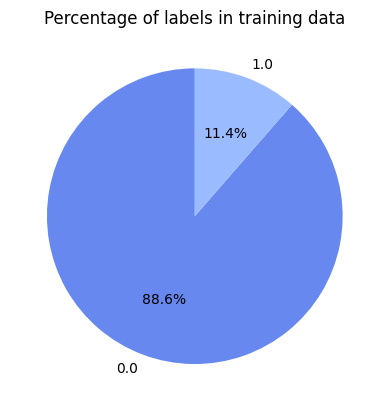

In [ ]:
plt.pie(y_train.value_counts(normalize=True).values, labels=y_train.value_counts(normalize=True).index, colors=sns.color_palette('coolwarm'), autopct='%1.1f%%', startangle=90)
plt.title('Percentage of labels in training data')
plt.show()

## 4.3: Training a Classification Model

### Using Logistic Regression, Decision Tree, Random Forest, SVC & KNN Classifiers and then selecting best based on metrics

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVC": SVC(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

In [ ]:
results = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    report = classification_report(y_test, y_pred, zero_division=0)

    results[name] = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "classification_report": report
    }
    print(f"{name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}\n")
    print(report)
    print("--"*50)


Training Logistic Regression...
Logistic Regression - Accuracy: 0.9087, Precision: 0.7143, Recall: 0.3297, F1-score: 0.4511

              precision    recall  f1-score   support

         0.0       0.92      0.98      0.95      1418
         1.0       0.71      0.33      0.45       182

    accuracy                           0.91      1600
   macro avg       0.82      0.66      0.70      1600
weighted avg       0.90      0.91      0.89      1600

----------------------------------------------------------------------------------------------------
Training Decision Tree...
Decision Tree - Accuracy: 0.9581, Precision: 0.8212, Recall: 0.8077, F1-score: 0.8144

              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      1418
         1.0       0.82      0.81      0.81       182

    accuracy                           0.96      1600
   macro avg       0.90      0.89      0.90      1600
weighted avg       0.96      0.96      0.96      1600

-------

From these metrics above Decision Tree is best for this classification

## 4.4: Hyperparameter Tuning of Decision Tree

In [ ]:
param_grid_dt = {
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
    }

dt_classifier = DecisionTreeClassifier(random_state=42)
grid_search_dt = GridSearchCV(estimator=dt_classifier, param_grid=param_grid_dt, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_search_dt.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [10, 20, 30, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='f1', verbose=1)

In [ ]:
best_dt_model = grid_search_dt.best_estimator_

y_pred_tuned_dt = best_dt_model.predict(X_test)

accuracy_tuned_dt = accuracy_score(y_test, y_pred_tuned_dt)
precision_tuned_dt = precision_score(y_test, y_pred_tuned_dt, zero_division=0)
recall_tuned_dt = recall_score(y_test, y_pred_tuned_dt, zero_division=0)
f1_tuned_dt = f1_score(y_test, y_pred_tuned_dt, zero_division=0)
report_tuned_dt = classification_report(y_test, y_pred_tuned_dt, zero_division=0)

print("Best Decision Tree Model (Tuned):")
print(f"Accuracy: {accuracy_tuned_dt:.4f}")
print(f"Precision: {precision_tuned_dt:.4f}")
print(f"Recall: {recall_tuned_dt:.4f}")
print(f"F1-score: {f1_tuned_dt:.4f}")
print("Classification Report:")
print(report_tuned_dt)

print("Best Hyperparameters found by GridSearchCV:")
print(grid_search_dt.best_params_)

Best Decision Tree Model (Tuned):
Accuracy: 0.9637
Precision: 0.8523
Recall: 0.8242
F1-score: 0.8380
Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      1418
         1.0       0.85      0.82      0.84       182

    accuracy                           0.96      1600
   macro avg       0.91      0.90      0.91      1600
weighted avg       0.96      0.96      0.96      1600

Best Hyperparameters found by GridSearchCV:
{'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2}


## Confusion Matrix

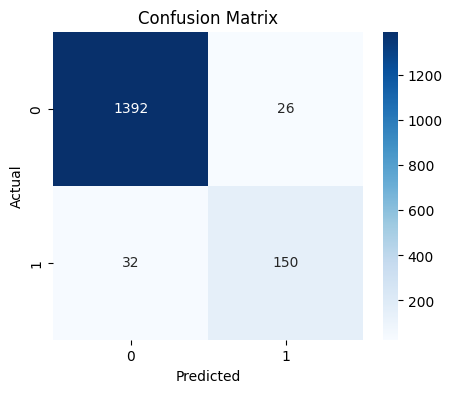

In [ ]:
cm = confusion_matrix(y_test, y_pred_tuned_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 4.5: Saving the Model

In [ ]:
joblib.dump(best_dt_model, 'best_dt_model.joblib')
print("Model saved successfully as 'best_dt_model.joblib'")

Model saved successfully as 'best_dt_model.joblib'
